In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

# Load dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Define columns
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels
data[text_column] = data[text_column].fillna("missing")

# TF-IDF Vectorization
max_features = 5000  # Maximum number of features in TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
X = tfidf_vectorizer.fit_transform(data[text_column])

# Dimensionality Reduction using SVD
svd_components = 300  # Reduce dimensions to 300
svd = TruncatedSVD(n_components=svd_components, random_state=42)
X_reduced = svd.fit_transform(X)

# Reshape data to be 3D for LSTM (adding an extra "timesteps" dimension)
X_reduced = X_reduced.reshape(X_reduced.shape[0], 1, X_reduced.shape[1])

# Extract target values
y = data[target_column].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Build LSTM Model
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_reduced.shape[1], X_reduced.shape[2]), return_sequences=False),  # LSTM layer
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("Training LSTM Model...")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {accuracy * 100:.2f}%")

# Save model
model_path = r"C:\Users\PC\Downloads\LSTM_TFIDF_model.h5"
model.save(model_path)
print(f"Trained LSTM model saved to {model_path}")

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training LSTM Model...
Epoch 1/10
4641/4641 [==============================] - 71s 9ms/step - loss: 0.2433 - accuracy: 0.9053 - val_loss: 0.2218 - val_accuracy: 0.9143
Epoch 2/10
4641/4641 [==============================] - 38s 8ms/step - loss: 0.2228 - accuracy: 0.9151 - val_loss: 0.2195 - val_accuracy: 0.9152
Epoch 3/10
4641/4641 [==============================] - 36s 8ms/step - loss: 0.2183 - accuracy: 0.9167 - val_loss: 0.2145 - val_accuracy: 0.9148
Epoch 4/10
4641/4641 [==============================] - 34s 7ms/step - loss: 0.2132 - accuracy: 0.9183 - val_loss: 0.2122 - val_accuracy: 0.9180
Epoch 5/10
4641/4641 [==============================] - 37s 8ms/step - loss: 0.2074 - accuracy: 0.9210 - val_loss: 0.2057 - val_accuracy: 0.9198
Epoch 6/10
4641/4641 [==============================] - 38s 8ms/step - loss: 0.2021 - accuracy: 0.9233 - val_loss: 0.2063 - val_accuracy: 0.9193
Epoch 7/10
4641/4641 [==============================] - 36s 8ms/step - loss: 0.1988 - accuracy: 0.9243 - va

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Trained LSTM model saved to C:\Users\PC\Downloads\LSTM_TFIDF_model.h5
1451/1451 [==============================] - 11s 4ms/step
Accuracy: 92.60%
Precision: 92.69%
Recall: 92.46%
F1 Score: 92.58%
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     23238
           1       0.93      0.92      0.93     23171

    accuracy                           0.93     46409
   macro avg       0.93      0.93      0.93     46409
weighted avg       0.93      0.93      0.93     46409



1451/1451 [==============================] - 11s 7ms/step


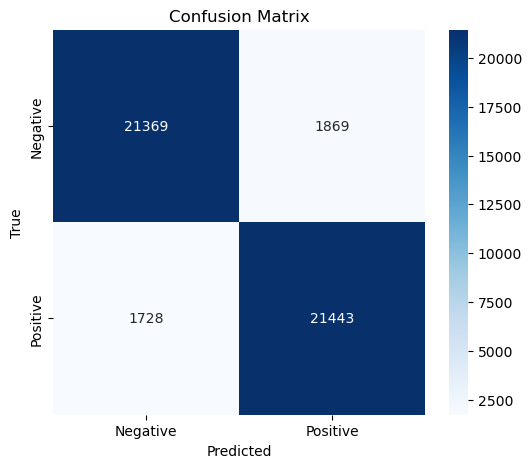

In [3]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have already trained the model and made predictions (as per the previous code)
# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


1451/1451 [==============================] - 11s 7ms/step


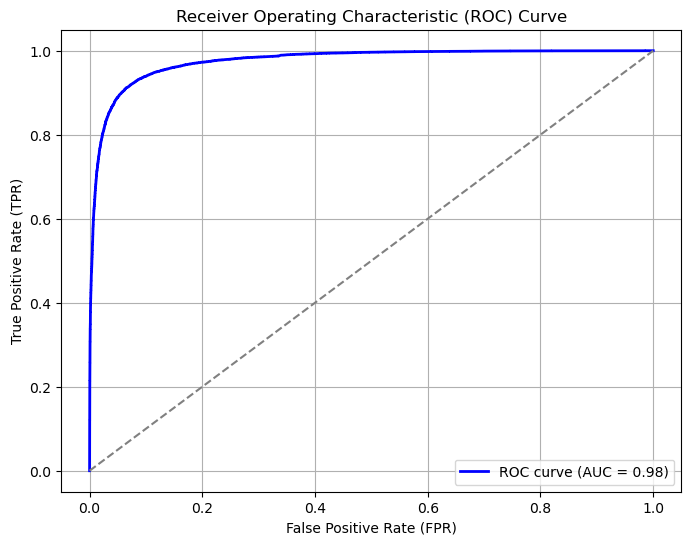

In [4]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have already trained the model and made predictions (as per the previous code)
# Make predictions (probabilities for ROC curve, not binary labels)
y_pred_prob = model.predict(X_test)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (chance level)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


1451/1451 [==============================] - 10s 6ms/step
Mean Absolute Error (MAE): 0.0775
Mean Squared Error (MSE): 0.0775
Root Mean Squared Error (RMSE): 0.2784


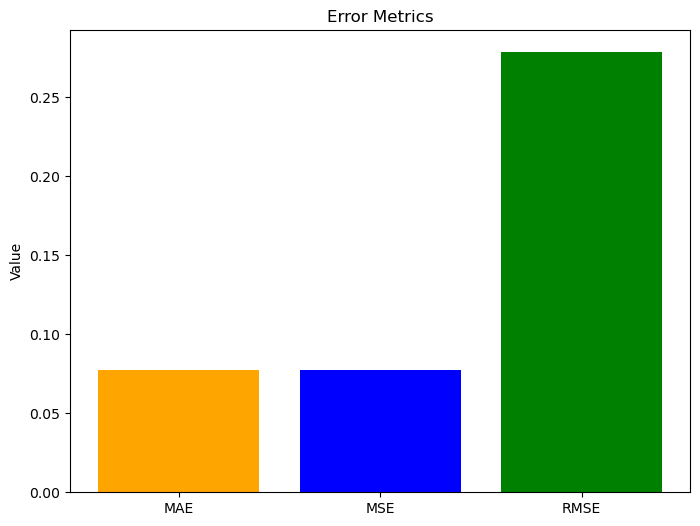

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming you have already trained the model and made predictions (as per the previous code)
# Make predictions (probabilities for the error metrics)
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary predictions for error metrics
y_pred_binary = (y_pred_prob > 0.5).astype("int32")

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_binary)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_binary)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Display the metrics
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Bar plot for error metrics
plt.figure(figsize=(8, 6))
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]
plt.bar(metrics, values, color=['orange', 'blue', 'green'])
plt.title('Error Metrics')
plt.ylabel('Value')

plt.show()


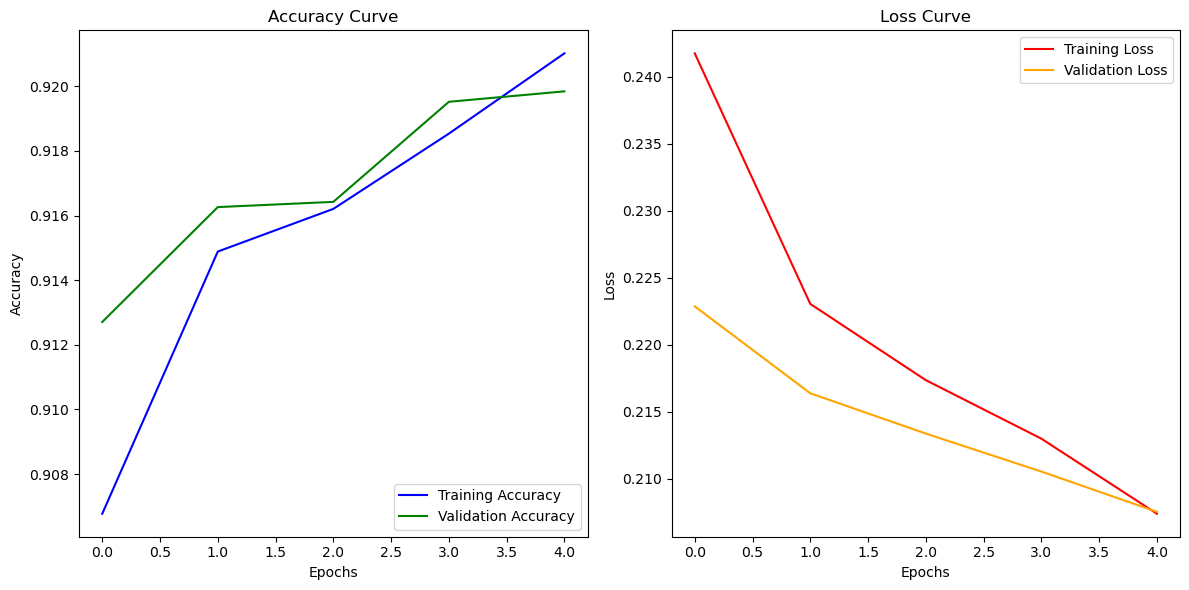

In [7]:
import matplotlib.pyplot as plt

# Assuming `history` contains the training history from `model.fit()`

# Plot Accuracy Curve
plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Display the plots
plt.tight_layout()
plt.show()
